# SHAP Explanations for the Frozen Credit-Risk Model

This notebook applies SHAP to the already trained and frozen XGBoost classifier. It produces reproducible global and local feature attributions for the exact held-out applicants. It does not retrain the model, refit preprocessing, run LIME or DiCE, or make legal or comparative-method claims.

In [9]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import xgboost as xgb
from sklearn.metrics import (
    average_precision_score, confusion_matrix, f1_score, precision_score,
    recall_score, roc_auc_score,
)
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
TARGET = "TARGET"

## 1. Load Frozen Artifacts

In [10]:
ARTIFACTS_DIR = Path("../artifacts")
MODEL_PATH = ARTIFACTS_DIR / "xgboost_credit_model.joblib"
PREPROCESSOR_PATH = ARTIFACTS_DIR / "preprocessor.joblib"
MODEL_METADATA_PATH = ARTIFACTS_DIR / "model_metadata.json"
TEST_INDICES_PATH = ARTIFACTS_DIR / "test_indices.csv"
PREPROCESSING_METADATA_PATH = ARTIFACTS_DIR / "preprocessing_metadata.csv"
PRIMARY_FEATURES_PATH = ARTIFACTS_DIR / "primary_features.json"

model = joblib.load(MODEL_PATH)
preprocessor = joblib.load(PREPROCESSOR_PATH)
with MODEL_METADATA_PATH.open(encoding="utf-8") as file:
    model_metadata = json.load(file)
test_indices = pd.read_csv(TEST_INDICES_PATH)
preprocessing_metadata = pd.read_csv(PREPROCESSING_METADATA_PATH)
with PRIMARY_FEATURES_PATH.open(encoding="utf-8") as file:
    saved_modelling_features = json.load(file)

decision_threshold = float(model_metadata["decision_threshold"])
assert hasattr(model, "classes_"), "The saved model is not fitted."
print(f"Selected model: {model_metadata['selected_model']}")
print(f"Decision threshold: {decision_threshold}")
print(f"Transformed feature count: {model_metadata['transformed_feature_count']}")
print(f"Saved test indexes: {len(test_indices)}")

Selected model: Weighted XGBoost
Decision threshold: 0.5
Transformed feature count: 28
Saved test indexes: 61503


## 2. Reconstruct the Exact Modelling Data and Held-Out Cases

In [11]:
DATA_PATH = Path("../data/raw/application_train.csv")
ORIGINAL_FEATURES = [
    "NAME_CONTRACT_TYPE", "AMT_INCOME_TOTAL", "AMT_CREDIT",
    "AMT_ANNUITY", "AMT_GOODS_PRICE", "DAYS_EMPLOYED",
    "NAME_INCOME_TYPE", "NAME_HOUSING_TYPE", "CNT_FAM_MEMBERS",
    "AMT_REQ_CREDIT_BUREAU_MON", "AMT_REQ_CREDIT_BUREAU_QRT",
    "AMT_REQ_CREDIT_BUREAU_YEAR",
]
raw_df = pd.read_csv(DATA_PATH)
modelling_df = raw_df[ORIGINAL_FEATURES + [TARGET]].copy()
employment_days = modelling_df["DAYS_EMPLOYED"].mask(modelling_df["DAYS_EMPLOYED"].eq(365243), np.nan)
modelling_df["EMPLOYMENT_YEARS"] = employment_days.abs().div(365.25)
modelling_df = modelling_df.drop(columns=["DAYS_EMPLOYED"])

def safe_ratio(numerator, denominator):
    return numerator.div(denominator.mask(denominator.eq(0), np.nan))

def recalculate_ratios(frame):
    frame = frame.copy()
    frame["CREDIT_INCOME_RATIO"] = safe_ratio(frame["AMT_CREDIT"], frame["AMT_INCOME_TOTAL"])
    frame["ANNUITY_INCOME_RATIO"] = safe_ratio(frame["AMT_ANNUITY"], frame["AMT_INCOME_TOTAL"])
    frame["CREDIT_ANNUITY_RATIO"] = safe_ratio(frame["AMT_CREDIT"], frame["AMT_ANNUITY"])
    return frame.replace([np.inf, -np.inf], np.nan)

modelling_df = recalculate_ratios(modelling_df)
modelling_feature_names = modelling_df.columns.drop(TARGET).tolist()
assert modelling_feature_names == saved_modelling_features
assert test_indices.columns.tolist() == ["row_index"]
assert test_indices["row_index"].is_unique
saved_test_index = pd.Index(test_indices["row_index"].astype(int))
assert saved_test_index.isin(modelling_df.index).all()

X_test_raw = modelling_df.loc[saved_test_index, modelling_feature_names].copy()
y_test = modelling_df.loc[saved_test_index, TARGET].copy()
X_test_processed = preprocessor.transform(X_test_raw)
processed_values = X_test_processed.data if hasattr(X_test_processed, "data") and not isinstance(X_test_processed, np.ndarray) else np.asarray(X_test_processed)
processed_nan_count = int(np.isnan(processed_values).sum())
print(f"Exact held-out rows: {len(X_test_raw)}")
print(f"Processed shape: {X_test_processed.shape}")
print(f"NaN values after preprocessing: {processed_nan_count}")
assert len(X_test_raw) == len(test_indices)
assert processed_nan_count == 0

Exact held-out rows: 61503
Processed shape: (61503, 28)
NaN values after preprocessing: 0


## 3. Retrieve and Map Transformed Feature Names

In [12]:
transformed_feature_names = preprocessor.get_feature_names_out()
assert len(transformed_feature_names) == X_test_processed.shape[1]
metadata_by_transformed = preprocessing_metadata.set_index("transformed_feature")
assert pd.Index(transformed_feature_names).isin(metadata_by_transformed.index).all()

DISPLAY_NAMES = {
    "NAME_CONTRACT_TYPE": "Contract type",
    "AMT_INCOME_TOTAL": "Annual income",
    "AMT_CREDIT": "Requested credit amount",
    "AMT_ANNUITY": "Annuity amount",
    "AMT_GOODS_PRICE": "Goods price",
    "EMPLOYMENT_YEARS": "Employment duration",
    "NAME_INCOME_TYPE": "Income type",
    "NAME_HOUSING_TYPE": "Housing type",
    "CNT_FAM_MEMBERS": "Family members",
    "AMT_REQ_CREDIT_BUREAU_MON": "Credit enquiries in previous month",
    "AMT_REQ_CREDIT_BUREAU_QRT": "Credit enquiries in previous quarter",
    "AMT_REQ_CREDIT_BUREAU_YEAR": "Credit enquiries in previous year",
    "CREDIT_INCOME_RATIO": "Credit-to-income ratio",
    "ANNUITY_INCOME_RATIO": "Annuity-to-income ratio",
    "CREDIT_ANNUITY_RATIO": "Credit-to-annuity ratio",
}

def readable_transformed_name(transformed_feature):
    original = metadata_by_transformed.at[transformed_feature, "original_feature"]
    base = DISPLAY_NAMES.get(original, original.replace("_", " " ).title())
    categorical_prefix = f"categorical__{original}_"
    if transformed_feature.startswith(categorical_prefix):
        category = transformed_feature[len(categorical_prefix):].replace("_", " ")
        return f"{base}: {category}"
    return base

readable_feature_names = [readable_transformed_name(name) for name in transformed_feature_names]
display_feature_names = readable_feature_names
feature_name_mapping = pd.DataFrame({
    "transformed_feature": transformed_feature_names,
    "display_feature": readable_feature_names,
})
display(feature_name_mapping)

,transformed_feature,display_feature
0,numeric__AMT_INCOME_TOTAL,Annual income
1,numeric__AMT_CREDIT,Requested credit amount
2,numeric__AMT_ANNUITY,Annuity amount
3,numeric__AMT_GOODS_PRICE,Goods price
4,numeric__CNT_FAM_MEMBERS,Family members
5,numeric__AMT_REQ_CREDIT_BUREAU_MON,Credit enquiries in previous month
6,numeric__AMT_REQ_CREDIT_BUREAU_QRT,Credit enquiries in previous quarter
7,numeric__AMT_REQ_CREDIT_BUREAU_YEAR,Credit enquiries in previous year
8,numeric__EMPLOYMENT_YEARS,Employment duration
9,numeric__CREDIT_INCOME_RATIO,Credit-to-income ratio


## 4. Reproduce Frozen-Model Predictions

In [13]:
test_probabilities = model.predict_proba(X_test_processed)[:, 1]
test_predictions = (test_probabilities >= decision_threshold).astype(int)
reproduced_metrics = {
    "roc_auc": roc_auc_score(y_test, test_probabilities),
    "pr_auc": average_precision_score(y_test, test_probabilities),
    "precision_positive": precision_score(y_test, test_predictions, zero_division=0),
    "recall_positive": recall_score(y_test, test_predictions, zero_division=0),
    "f1_positive": f1_score(y_test, test_predictions, zero_division=0),
}
display(pd.Series(reproduced_metrics, name="reproduced_value").to_frame())
display(pd.DataFrame(confusion_matrix(y_test, test_predictions), index=["Actual 0", "Actual 1"], columns=["Predicted 0", "Predicted 1"]))
for metric in reproduced_metrics:
    if metric in model_metadata:
        print(f"{metric} difference from saved metadata: {reproduced_metrics[metric] - float(model_metadata[metric]):.10f}")

,reproduced_value
roc_auc,0.692518
pr_auc,0.167144
precision_positive,0.138796
recall_positive,0.621551
f1_positive,0.226920


,Predicted 0,Predicted 1
Actual 0,37390,19148
Actual 1,1879,3086


roc_auc difference from saved metadata: 0.0000000000
pr_auc difference from saved metadata: 0.0000000000
precision_positive difference from saved metadata: 0.0000000000
recall_positive difference from saved metadata: 0.0000000000
f1_positive difference from saved metadata: 0.0000000000


## 5. Select Fixed Cross-Method XAI Evaluation Cases

In [14]:
case_candidates = pd.DataFrame({
    "row_index": X_test_raw.index.to_numpy(),
    "true_target": y_test.to_numpy(),
    "predicted_class": test_predictions,
    "predicted_probability": test_probabilities,
})
case_candidates["threshold_distance"] = (case_candidates["predicted_probability"] - decision_threshold).abs()

def select_class_cases(predicted_class):
    group = case_candidates.loc[case_candidates["predicted_class"].eq(predicted_class)].copy()
    if predicted_class == 1:
        confident = group.sort_values(["predicted_probability", "row_index"], ascending=[False, True]).head(5).assign(case_type="high-confidence positive")
        borderline = group.sort_values(["threshold_distance", "row_index"]).head(10).assign(case_type="borderline positive")
    else:
        confident = group.sort_values(["predicted_probability", "row_index"]).head(5).assign(case_type="high-confidence negative")
        borderline = group.sort_values(["threshold_distance", "row_index"]).head(10).assign(case_type="borderline negative")
    selected = pd.concat([confident, borderline]).drop_duplicates("row_index").head(10)
    if len(selected) < 10:
        fallback = group.loc[~group["row_index"].isin(selected["row_index"])].sort_values("row_index").assign(case_type="deterministic class fallback")
        selected = pd.concat([selected, fallback]).head(10)
    return selected

xai_cases = pd.concat([select_class_cases(1), select_class_cases(0)], ignore_index=True)
xai_cases.insert(0, "case_id", [f"XAI_{number:03d}" for number in range(1, len(xai_cases) + 1)])
xai_cases = xai_cases[["case_id", "row_index", "true_target", "predicted_class", "predicted_probability", "case_type"]]
XAI_CASES_PATH = ARTIFACTS_DIR / "xai_evaluation_cases.csv"
xai_cases.to_csv(XAI_CASES_PATH, index=False)
display(xai_cases)
assert xai_cases.groupby("predicted_class").size().to_dict() == {0: 10, 1: 10}

,case_id,row_index,true_target,predicted_class,predicted_probability,case_type
0,XAI_001,288644,0,1,0.871334,high-confidence positive
1,XAI_002,234361,0,1,0.861796,high-confidence positive
2,XAI_003,25106,1,1,0.851671,high-confidence positive
3,XAI_004,148440,0,1,0.845883,high-confidence positive
4,XAI_005,267529,0,1,0.844541,high-confidence positive
5,XAI_006,259190,0,1,0.500000,borderline positive
6,XAI_007,125832,0,1,0.500008,borderline positive
7,XAI_008,3508,0,1,0.500023,borderline positive
8,XAI_009,264908,0,1,0.500030,borderline positive
9,XAI_010,253960,0,1,0.500040,borderline positive


## 6. Select a Reproducible SHAP Sample

In [15]:
SHAP_SAMPLE_SIZE = min(1000, len(X_test_raw))
fixed_positions = X_test_raw.index.get_indexer(xai_cases["row_index"])
all_positions = np.arange(len(X_test_raw))
remaining_positions = np.setdiff1d(all_positions, fixed_positions, assume_unique=False)
remaining_needed = SHAP_SAMPLE_SIZE - len(fixed_positions)
sampled_positions, _ = train_test_split(
    remaining_positions, train_size=remaining_needed, random_state=RANDOM_STATE,
    stratify=test_predictions[remaining_positions],
)
shap_positions = np.concatenate([fixed_positions, np.sort(sampled_positions)])
X_shap_processed = X_test_processed[shap_positions]
X_shap_dense = X_shap_processed.toarray() if hasattr(X_shap_processed, "toarray") else np.asarray(X_shap_processed)
print(f"SHAP sample size: {len(shap_positions)}")
print("Predicted class distribution:")
display(pd.Series(test_predictions[shap_positions]).value_counts().sort_index())
print("True class distribution:")
display(y_test.iloc[shap_positions].value_counts().sort_index())
assert set(fixed_positions).issubset(set(shap_positions))

SHAP sample size: 1000
Predicted class distribution:


0    636
1    364
Name: count, dtype: int64

True class distribution:


TARGET
0    908
1     92
Name: count, dtype: int64

## 7. Compute Native XGBoost Tree SHAP Contributions

In [16]:
booster = model.get_booster()
assert X_shap_dense.shape == (1000, 28)
X_shap_dmatrix = xgb.DMatrix(
    X_shap_dense, feature_names=list(transformed_feature_names)
)
shap_contribs = booster.predict(X_shap_dmatrix, pred_contribs=True)
shap_values = shap_contribs[:, :-1]
base_values = shap_contribs[:, -1]
base_value = float(base_values[0])
model_output_space = "raw margin / log-odds"
shap_explanation = shap.Explanation(
    values=shap_values,
    base_values=base_values,
    data=X_shap_dense,
    feature_names=list(display_feature_names),
)
print(f"Raw contribution matrix shape: {shap_contribs.shape}")
print(f"SHAP matrix shape: {shap_values.shape}")
print(f"Explained samples: {shap_values.shape[0]}")
print(f"Explained features: {shap_values.shape[1]}")
print(f"Base value: {base_value}")
print(f"Model output space: {model_output_space}")
assert shap_values.shape == X_shap_dense.shape
assert shap_values.shape[1] == len(transformed_feature_names)
assert np.isfinite(shap_values).all()
assert np.isfinite(base_values).all()
assert shap_explanation.values.shape == (1000, 28)

Raw contribution matrix shape: (1000, 29)
SHAP matrix shape: (1000, 28)
Explained samples: 1000
Explained features: 28
Base value: 0.008677801117300987
Model output space: raw margin / log-odds


### SHAP–XGBoost Compatibility

The frozen model uses XGBoost 3.2.0 and this environment uses SHAP 0.49.1. Direct `shap.TreeExplainer(model)` construction raised a `base_score` parsing error for the XGBoost 3.x model representation. XGBoost's native `pred_contribs=True` Tree SHAP implementation is therefore used to compute contributions, while SHAP remains responsible for explanation objects and visualisation. The model, preprocessing, fixed test cases, and predictions are unchanged. Native contributions are validated below against the model's raw-margin output.

    ## 8. SHAP Additivity Sanity Check

The base value is the explainer's reference model output. Positive SHAP values increase the model risk output relative to that reference; negative values decrease it. TreeExplainer commonly reports the raw XGBoost margin (log-odds for binary logistic models), so the additive total must be compared with the model margin—not directly with probability—unless the explainer explicitly uses probability output.

In [17]:
raw_margin = booster.predict(X_shap_dmatrix, output_margin=True)
reconstructed_margin = shap_values.sum(axis=1) + base_values
max_additivity_difference = float(np.max(np.abs(raw_margin - reconstructed_margin)))
print(f"Maximum raw-margin additivity difference: {max_additivity_difference:.10g}")
assert np.allclose(raw_margin, reconstructed_margin, atol=1e-5)

def sigmoid(values):
    return 1.0 / (1.0 + np.exp(-values))

reconstructed_probability = sigmoid(reconstructed_margin)
model_probability = model.predict_proba(X_shap_processed)[:, 1]
max_probability_difference = float(np.max(np.abs(reconstructed_probability - model_probability)))
print(f"Maximum reconstructed-probability difference: {max_probability_difference:.10g}")
assert np.allclose(reconstructed_probability, model_probability, atol=1e-5)

Maximum raw-margin additivity difference: 2.384185791e-06
Maximum reconstructed-probability difference: 3.278255463e-07


## 9–10. Global Importance and SHAP Summary Plot

,feature,mean_abs_shap
0,Goods price,0.265513
1,Credit-to-annuity ratio,0.256917
2,Employment duration,0.221947
3,Income type: Working,0.103671
4,Annuity amount,0.087438
5,Requested credit amount,0.078338
6,Contract type: Cash loans,0.075303
7,Annuity-to-income ratio,0.040478
8,Credit enquiries in previous year,0.035643
9,Credit enquiries in previous quarter,0.034572


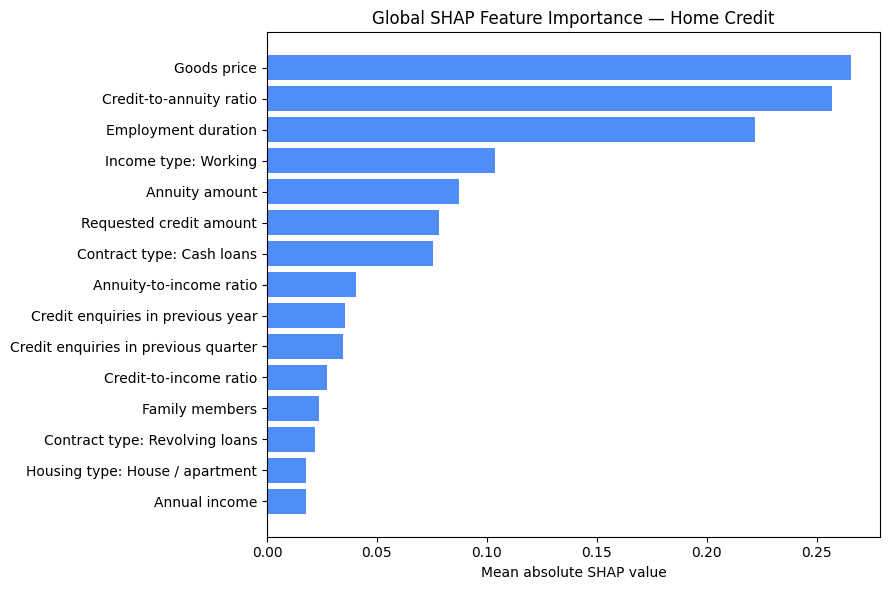

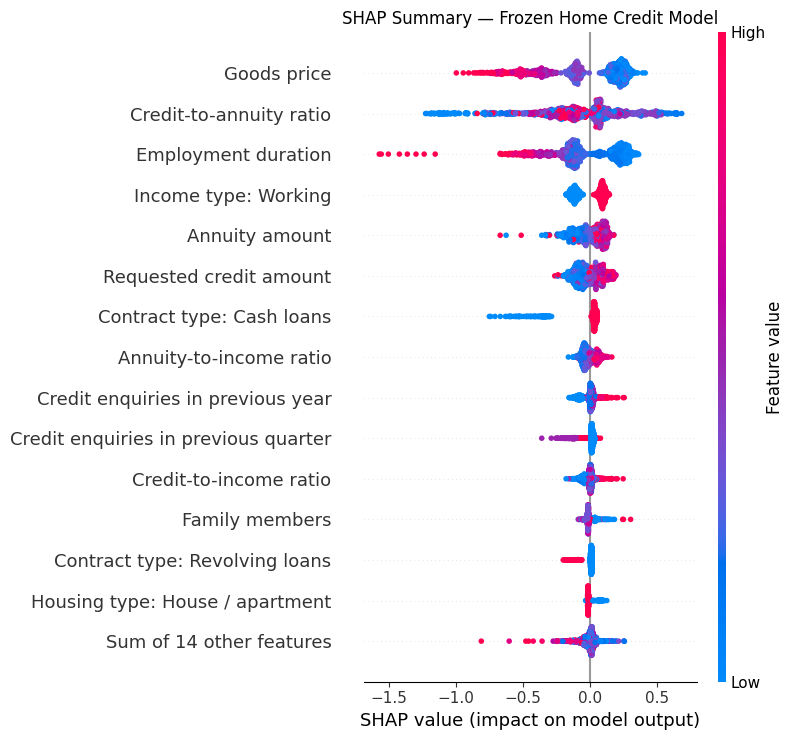

In [18]:
shap_global_importance = pd.DataFrame({
    "feature": readable_feature_names,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
SHAP_GLOBAL_PATH = ARTIFACTS_DIR / "shap_global_importance.csv"
shap_global_importance.to_csv(SHAP_GLOBAL_PATH, index=False)
display(shap_global_importance.head(15))

top_global = shap_global_importance.head(15).sort_values("mean_abs_shap")
plt.figure(figsize=(9, 6))
plt.barh(top_global["feature"], top_global["mean_abs_shap"], color="#4F8EF7")
plt.xlabel("Mean absolute SHAP value")
plt.title("Global SHAP Feature Importance — Home Credit")
plt.tight_layout()
plt.show()

PLOTS_DIR = ARTIFACTS_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
SHAP_SUMMARY_PLOT_PATH = PLOTS_DIR / "shap_summary.png"
shap.plots.beeswarm(shap_explanation, max_display=15, show=False)
plt.title("SHAP Summary — Frozen Home Credit Model")
plt.tight_layout()
plt.savefig(SHAP_SUMMARY_PLOT_PATH, dpi=160, bbox_inches="tight")
plt.show()

## 11–12. Local SHAP Explanations and Top Factors

In [19]:
X_fixed_processed = X_test_processed[fixed_positions]
X_fixed_dense = X_fixed_processed.toarray() if hasattr(X_fixed_processed, "toarray") else np.asarray(X_fixed_processed)
X_fixed_dmatrix = xgb.DMatrix(X_fixed_dense, feature_names=list(transformed_feature_names))
fixed_contribs = booster.predict(X_fixed_dmatrix, pred_contribs=True)
local_shap_values = fixed_contribs[:, :-1]
local_base_values = fixed_contribs[:, -1]
assert local_shap_values.shape == X_fixed_dense.shape
local_records = []
for case_position, case in enumerate(xai_cases.itertuples(index=False)):
    raw_row = X_test_raw.loc[case.row_index]
    for feature_position, transformed_feature in enumerate(transformed_feature_names):
        original_feature = metadata_by_transformed.at[transformed_feature, "original_feature"]
        contribution = float(local_shap_values[case_position, feature_position])
        raw_value = raw_row.get(original_feature, np.nan)
        local_records.append({
            "case_id": case.case_id,
            "row_index": int(case.row_index),
            "true_target": int(case.true_target),
            "predicted_class": int(case.predicted_class),
            "predicted_probability": float(case.predicted_probability),
            "base_value": float(local_base_values[case_position]),
            "transformed_feature": transformed_feature,
            "original_feature": original_feature,
            "display_feature": readable_feature_names[feature_position],
            "display_value": raw_value,
            "shap_value": contribution,
            "absolute_shap_value": abs(contribution),
            "direction": "increases model risk output" if contribution > 0 else "decreases model risk output",
        })
local_explanations = pd.DataFrame(local_records)
SHAP_LOCAL_PATH = ARTIFACTS_DIR / "shap_local_explanations.csv"
local_explanations.to_csv(SHAP_LOCAL_PATH, index=False)

shap_top_factors = (
    local_explanations.sort_values(["case_id", "absolute_shap_value"], ascending=[True, False])
    .groupby("case_id", sort=False).head(5).copy()
)
shap_top_factors["rank"] = shap_top_factors.groupby("case_id").cumcount().add(1)
shap_top_factors = shap_top_factors[["case_id", "rank", "original_feature", "display_feature", "display_value", "shap_value", "direction"]]
SHAP_TOP_FACTORS_PATH = ARTIFACTS_DIR / "shap_top_factors.csv"
shap_top_factors.to_csv(SHAP_TOP_FACTORS_PATH, index=False)
display(shap_top_factors)

,case_id,rank,original_feature,display_feature,display_value,shap_value,direction
11,XAI_001,1,CREDIT_ANNUITY_RATIO,Credit-to-annuity ratio,20.457252,0.498725,increases model risk output
8,XAI_001,2,EMPLOYMENT_YEARS,Employment duration,1.46475,0.348211,increases model risk output
4,XAI_001,3,CNT_FAM_MEMBERS,Family members,6.0,0.305611,increases model risk output
3,XAI_001,4,AMT_GOODS_PRICE,Goods price,436500.0,0.273690,increases model risk output
21,XAI_001,5,NAME_INCOME_TYPE,Income type: Working,Working,0.117217,increases model risk output
...,...,...,...,...,...,...,...
544,XAI_020,1,NAME_CONTRACT_TYPE,Contract type: Cash loans,Revolving loans,-0.328820,decreases model risk output
540,XAI_020,2,EMPLOYMENT_YEARS,Employment duration,1.256674,0.309952,increases model risk output
535,XAI_020,3,AMT_GOODS_PRICE,Goods price,247500.0,0.161339,increases model risk output
534,XAI_020,4,AMT_ANNUITY,Annuity amount,12375.0,-0.104795,decreases model risk output


## 13. Representative Local Waterfall

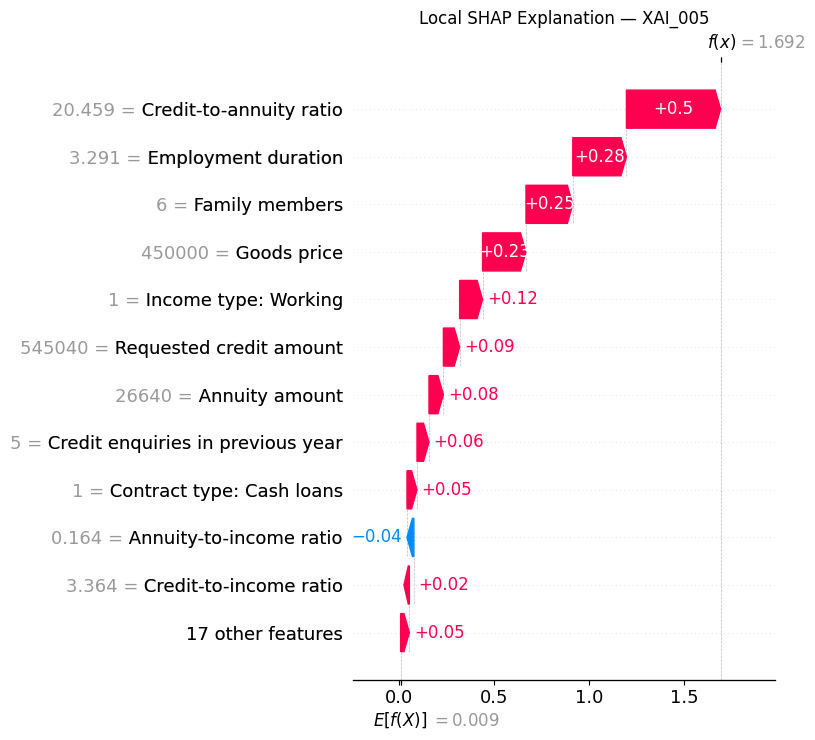

In [20]:
positive_cases = xai_cases.loc[xai_cases["predicted_class"].eq(1)].copy()
positive_cases["distance_from_threshold"] = positive_cases["predicted_probability"] - decision_threshold
representative_case = positive_cases.sort_values(["distance_from_threshold", "row_index"]).iloc[len(positive_cases) // 2]
representative_case_position = int(xai_cases.index[xai_cases["case_id"].eq(representative_case["case_id"])][0])
representative_explanation = shap.Explanation(
    values=local_shap_values[representative_case_position],
    base_values=float(local_base_values[representative_case_position]),
    data=X_fixed_dense[representative_case_position],
    feature_names=list(display_feature_names),
)
SHAP_WATERFALL_PATH = PLOTS_DIR / "shap_representative_waterfall.png"
shap.plots.waterfall(representative_explanation, max_display=12, show=False)
plt.title(f"Local SHAP Explanation — {representative_case['case_id']}")
plt.tight_layout()
plt.savefig(SHAP_WATERFALL_PATH, dpi=160, bbox_inches="tight")
plt.show()

## 14–15. Customer-Friendly Names and Rule-Based Plain English

Display names affect presentation only and never alter model inputs. Explanations below are deterministic templates, use attribution rather than causal language, and invoke no generative model or external API.

In [21]:
def plain_english_for_case(case_factors, maximum_factors=5):
    phrases = []
    for factor in case_factors.sort_values("rank").head(maximum_factors).itertuples():
        effect = "increased the model's predicted risk" if factor.shap_value > 0 else "reduced the model's predicted risk"
        phrases.append(f"{factor.display_feature} {effect}")
    if not phrases:
        return "No material feature attribution was available for this case."
    if len(phrases) == 1:
        return phrases[0] + "."
    return ", ".join(phrases[:-1]) + ", while " + phrases[-1] + "."

plain_english_records = []
for case in xai_cases.itertuples(index=False):
    factors = shap_top_factors.loc[shap_top_factors["case_id"].eq(case.case_id)]
    plain_english_records.append({
        "case_id": case.case_id,
        "predicted_probability": float(case.predicted_probability),
        "predicted_class": int(case.predicted_class),
        "plain_english_explanation": plain_english_for_case(factors),
    })
shap_plain_english = pd.DataFrame(plain_english_records)
SHAP_PLAIN_ENGLISH_PATH = ARTIFACTS_DIR / "shap_plain_english.csv"
shap_plain_english.to_csv(SHAP_PLAIN_ENGLISH_PATH, index=False)
display(shap_plain_english)

,case_id,predicted_probability,predicted_class,plain_english_explanation
0,XAI_001,0.871334,1,Credit-to-annuity ratio increased the model's ...
1,XAI_002,0.861796,1,Credit-to-annuity ratio increased the model's ...
2,XAI_003,0.851671,1,Credit-to-annuity ratio increased the model's ...
3,XAI_004,0.845883,1,Credit-to-annuity ratio increased the model's ...
4,XAI_005,0.844541,1,Credit-to-annuity ratio increased the model's ...
5,XAI_006,0.500000,1,Employment duration reduced the model's predic...
6,XAI_007,0.500008,1,Credit-to-annuity ratio increased the model's ...
7,XAI_008,0.500023,1,Contract type: Cash loans reduced the model's ...
8,XAI_009,0.500030,1,Goods price reduced the model's predicted risk...
9,XAI_010,0.500040,1,Goods price reduced the model's predicted risk...


## 16. SHAP Sparsity Preparation

In [22]:
def features_for_magnitude_fraction(absolute_values, fraction):
    ordered = np.sort(absolute_values)[::-1]
    total = ordered.sum()
    if total == 0:
        return 0
    return int(np.searchsorted(np.cumsum(ordered), fraction * total, side="left") + 1)

sparsity_records = []
for case_position, case in enumerate(xai_cases.itertuples(index=False)):
    absolute_values = np.abs(local_shap_values[case_position])
    sparsity_records.append({
        "case_id": case.case_id,
        "non_zero_feature_count": int(np.count_nonzero(absolute_values)),
        "features_for_50_percent": features_for_magnitude_fraction(absolute_values, 0.50),
        "features_for_80_percent": features_for_magnitude_fraction(absolute_values, 0.80),
    })
shap_sparsity_metrics = pd.DataFrame(sparsity_records)
SHAP_SPARSITY_PATH = ARTIFACTS_DIR / "shap_sparsity_metrics.csv"
shap_sparsity_metrics.to_csv(SHAP_SPARSITY_PATH, index=False)
display(shap_sparsity_metrics)

,case_id,non_zero_feature_count,features_for_50_percent,features_for_80_percent
0,XAI_001,25,3,7
1,XAI_002,25,3,7
2,XAI_003,25,3,7
3,XAI_004,25,3,7
4,XAI_005,25,3,6
5,XAI_006,25,4,8
6,XAI_007,25,4,8
7,XAI_008,25,3,8
8,XAI_009,25,3,6
9,XAI_010,25,3,6


## 17–18. Preliminary Stability and Faithfulness Sanity Checks

These small checks are preparation only, not formal cross-method stability or faithfulness benchmarks. Continuous, non-derived inputs receive a 1% perturbation with dependent ratios recalculated. The faithfulness check masks one top original feature to missing so the already-fitted preprocessor applies its learned imputation rule.

In [23]:
stability_features = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE", "EMPLOYMENT_YEARS"]
stability_records = []
faithfulness_records = []
for case in xai_cases.head(5).itertuples(index=False):
    original_position = int(X_test_raw.index.get_loc(case.row_index))
    case_position = int(xai_cases.index[xai_cases["case_id"].eq(case.case_id)][0])
    original_top = set(np.argsort(np.abs(local_shap_values[case_position]))[-5:])
    perturb_feature = next(feature for feature in stability_features if pd.notna(X_test_raw.at[case.row_index, feature]))
    perturbed_raw = X_test_raw.loc[[case.row_index]].copy()
    perturbed_raw[perturb_feature] = perturbed_raw[perturb_feature] * 1.01
    perturbed_raw = recalculate_ratios(perturbed_raw)
    perturbed_processed = preprocessor.transform(perturbed_raw)
    perturbed_dense = perturbed_processed.toarray() if hasattr(perturbed_processed, "toarray") else np.asarray(perturbed_processed)
    perturbed_dmatrix = xgb.DMatrix(perturbed_dense, feature_names=list(transformed_feature_names))
    perturbed_shap = booster.predict(perturbed_dmatrix, pred_contribs=True)[:, :-1]
    perturbed_top = set(np.argsort(np.abs(perturbed_shap[0]))[-5:])
    stability_records.append({
        "case_id": case.case_id, "perturbed_feature": perturb_feature,
        "top_5_overlap_count": len(original_top.intersection(perturbed_top)),
    })

    top_local = shap_top_factors.loc[shap_top_factors["case_id"].eq(case.case_id)].iloc[0]
    masked_raw = X_test_raw.loc[[case.row_index]].copy()
    masked_raw[top_local.original_feature] = np.nan
    if top_local.original_feature in {"AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY"}:
        masked_raw = recalculate_ratios(masked_raw)
    masked_probability = float(model.predict_proba(preprocessor.transform(masked_raw))[:, 1][0])
    faithfulness_records.append({
        "case_id": case.case_id, "masked_top_feature": top_local.original_feature,
        "original_probability": float(case.predicted_probability),
        "masked_probability": masked_probability,
        "absolute_score_change": abs(float(case.predicted_probability) - masked_probability),
    })

stability_sanity_check = pd.DataFrame(stability_records)
faithfulness_sanity_check = pd.DataFrame(faithfulness_records)
display(stability_sanity_check)
display(faithfulness_sanity_check)

,case_id,perturbed_feature,top_5_overlap_count
0,XAI_001,AMT_INCOME_TOTAL,5
1,XAI_002,AMT_INCOME_TOTAL,5
2,XAI_003,AMT_INCOME_TOTAL,5
3,XAI_004,AMT_INCOME_TOTAL,5
4,XAI_005,AMT_INCOME_TOTAL,5


,case_id,masked_top_feature,original_probability,masked_probability,absolute_score_change
0,XAI_001,CREDIT_ANNUITY_RATIO,0.871334,0.815969,0.055365
1,XAI_002,CREDIT_ANNUITY_RATIO,0.861796,0.807788,0.054008
2,XAI_003,CREDIT_ANNUITY_RATIO,0.851671,0.788041,0.063630
3,XAI_004,CREDIT_ANNUITY_RATIO,0.845883,0.779369,0.066514
4,XAI_005,CREDIT_ANNUITY_RATIO,0.844541,0.779925,0.064616


## 19. Save SHAP Metadata

In [24]:
generated_artifacts = [
    XAI_CASES_PATH.name, SHAP_GLOBAL_PATH.name, SHAP_LOCAL_PATH.name,
    SHAP_TOP_FACTORS_PATH.name, SHAP_PLAIN_ENGLISH_PATH.name,
    SHAP_SPARSITY_PATH.name, f"plots/{SHAP_SUMMARY_PLOT_PATH.name}",
    f"plots/{SHAP_WATERFALL_PATH.name}", "shap_metadata.json",
]
shap_metadata = {
    "explanation_method": "Tree SHAP",
    "computation_backend": "XGBoost native pred_contribs",
    "visualisation_library": "SHAP",
    "shap_version": shap.__version__,
    "xgboost_version": xgb.__version__,
    "model_file": MODEL_PATH.name,
    "model_name": model_metadata["selected_model"],
    "decision_threshold": decision_threshold,
    "shap_sample_size": len(shap_positions),
    "fixed_xai_case_count": len(xai_cases),
    "transformed_feature_count": len(transformed_feature_names),
    "model_output_space": "raw margin / log-odds",
    "compatibility_note": "Native XGBoost Tree SHAP contributions were used because SHAP 0.49.1 TreeExplainer could not parse the XGBoost 3.x base_score representation; the trained model was unchanged.",
    "random_state": RANDOM_STATE,
    "generated_artifact_filenames": generated_artifacts,
}
SHAP_METADATA_PATH = ARTIFACTS_DIR / "shap_metadata.json"
with SHAP_METADATA_PATH.open("w", encoding="utf-8") as file:
    json.dump(shap_metadata, file, indent=2)

## 20. Final SHAP Quality Checks

In [25]:
assert len(test_indices) == len(X_test_raw)
assert X_test_raw.index.equals(saved_test_index)
assert shap_values.shape[1] == X_test_processed.shape[1]
assert local_explanations["case_id"].nunique() == len(xai_cases)
assert local_explanations.groupby("case_id").size().eq(len(transformed_feature_names)).all()
assert np.isfinite(local_explanations["shap_value"]).all()
assert not shap_plain_english["plain_english_explanation"].str.contains(r"numeric__|categorical__", regex=True).any()
required_outputs = [
    XAI_CASES_PATH, SHAP_GLOBAL_PATH, SHAP_LOCAL_PATH, SHAP_TOP_FACTORS_PATH,
    SHAP_PLAIN_ENGLISH_PATH, SHAP_SPARSITY_PATH, SHAP_SUMMARY_PLOT_PATH,
    SHAP_WATERFALL_PATH, SHAP_METADATA_PATH,
]
assert all(path.exists() for path in required_outputs)
print("Quality checks passed: frozen model used, preprocessor only transformed data, and exact saved test indexes were retained.")

Quality checks passed: frozen model used, preprocessor only transformed data, and exact saved test indexes were retained.


## SHAP Interpretation

- **Feature attribution:** _Discuss SHAP as an allocation of model output among input features._
- **Global and local explanations:** _Distinguish sample-level importance patterns from one-applicant contributions._
- **Contribution direction:** _Discuss positive and negative values relative to the explainer base value and output space._
- **Absolute importance:** _Explain why absolute values rank contribution magnitude regardless of direction._
- **Non-causality:** _Clarify that feature attributions are not causal effects._
- **Frozen model:** _Explain why explanations are generated from the saved, unchanged classifier._
- **Fixed cases:** _Explain why the same held-out applicants will be reused in later XAI notebooks._
- **Rule-based language:** _Explain why deterministic templates avoid introducing another AI system._
- **Communication limitations:** _Discuss the gap between technical attribution and customer-understandable information._

These are discussion placeholders, not final dissertation conclusions or comparisons with other XAI methods.

## 22. Final Summary

In [26]:
print(f"Frozen model loaded: {hasattr(model, 'classes_')}")
print(f"Exact test rows reconstructed: {len(X_test_raw)}")
print(f"SHAP sample size: {len(shap_positions)}")
print(f"Fixed XAI cases: {len(xai_cases)}")
print(f"Transformed feature count: {len(transformed_feature_names)}")
print(f"SHAP matrix shape: {shap_values.shape}")
print(f"Top global SHAP feature: {shap_global_importance.iloc[0]['feature']}")
print(f"Representative case ID: {representative_case['case_id']}")
print(f"Representative predicted probability: {representative_case['predicted_probability']:.6f}")
print(f"Local explanations saved: {SHAP_LOCAL_PATH.exists()}")
print(f"Plain-English explanations saved: {SHAP_PLAIN_ENGLISH_PATH.exists()}")
print(f"Sparsity preparation saved: {SHAP_SPARSITY_PATH.exists()}")
print(f"SHAP metadata saved: {SHAP_METADATA_PATH.exists()}")
print("Model retrained: False")
print("Preprocessor refitted: False")

Frozen model loaded: True
Exact test rows reconstructed: 61503
SHAP sample size: 1000
Fixed XAI cases: 20
Transformed feature count: 28
SHAP matrix shape: (1000, 28)
Top global SHAP feature: Goods price
Representative case ID: XAI_005
Representative predicted probability: 0.844541
Local explanations saved: True
Plain-English explanations saved: True
Sparsity preparation saved: True
SHAP metadata saved: True
Model retrained: False
Preprocessor refitted: False
